In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

DATA = Path.home() / "projects/knee-oa-classification/data/raw"
SPLITS = ["train", "val", "test"]
GRADES = [0, 1, 2, 3, 4]

records = [
    {"split": s, "grade": g, "path": p}
    for s in SPLITS for g in GRADES
    for p in sorted((DATA / s / str(g)).iterdir())
]
df = pd.DataFrame(records)
print("Total images:", len(df))
df.pivot_table(index="split", columns="grade", values="path", aggfunc="count")

Total images: 8260


grade,0,1,2,3,4
split,,,,,
test,639,296,447,223,51
train,2286,1046,1516,757,173
val,328,153,212,106,27


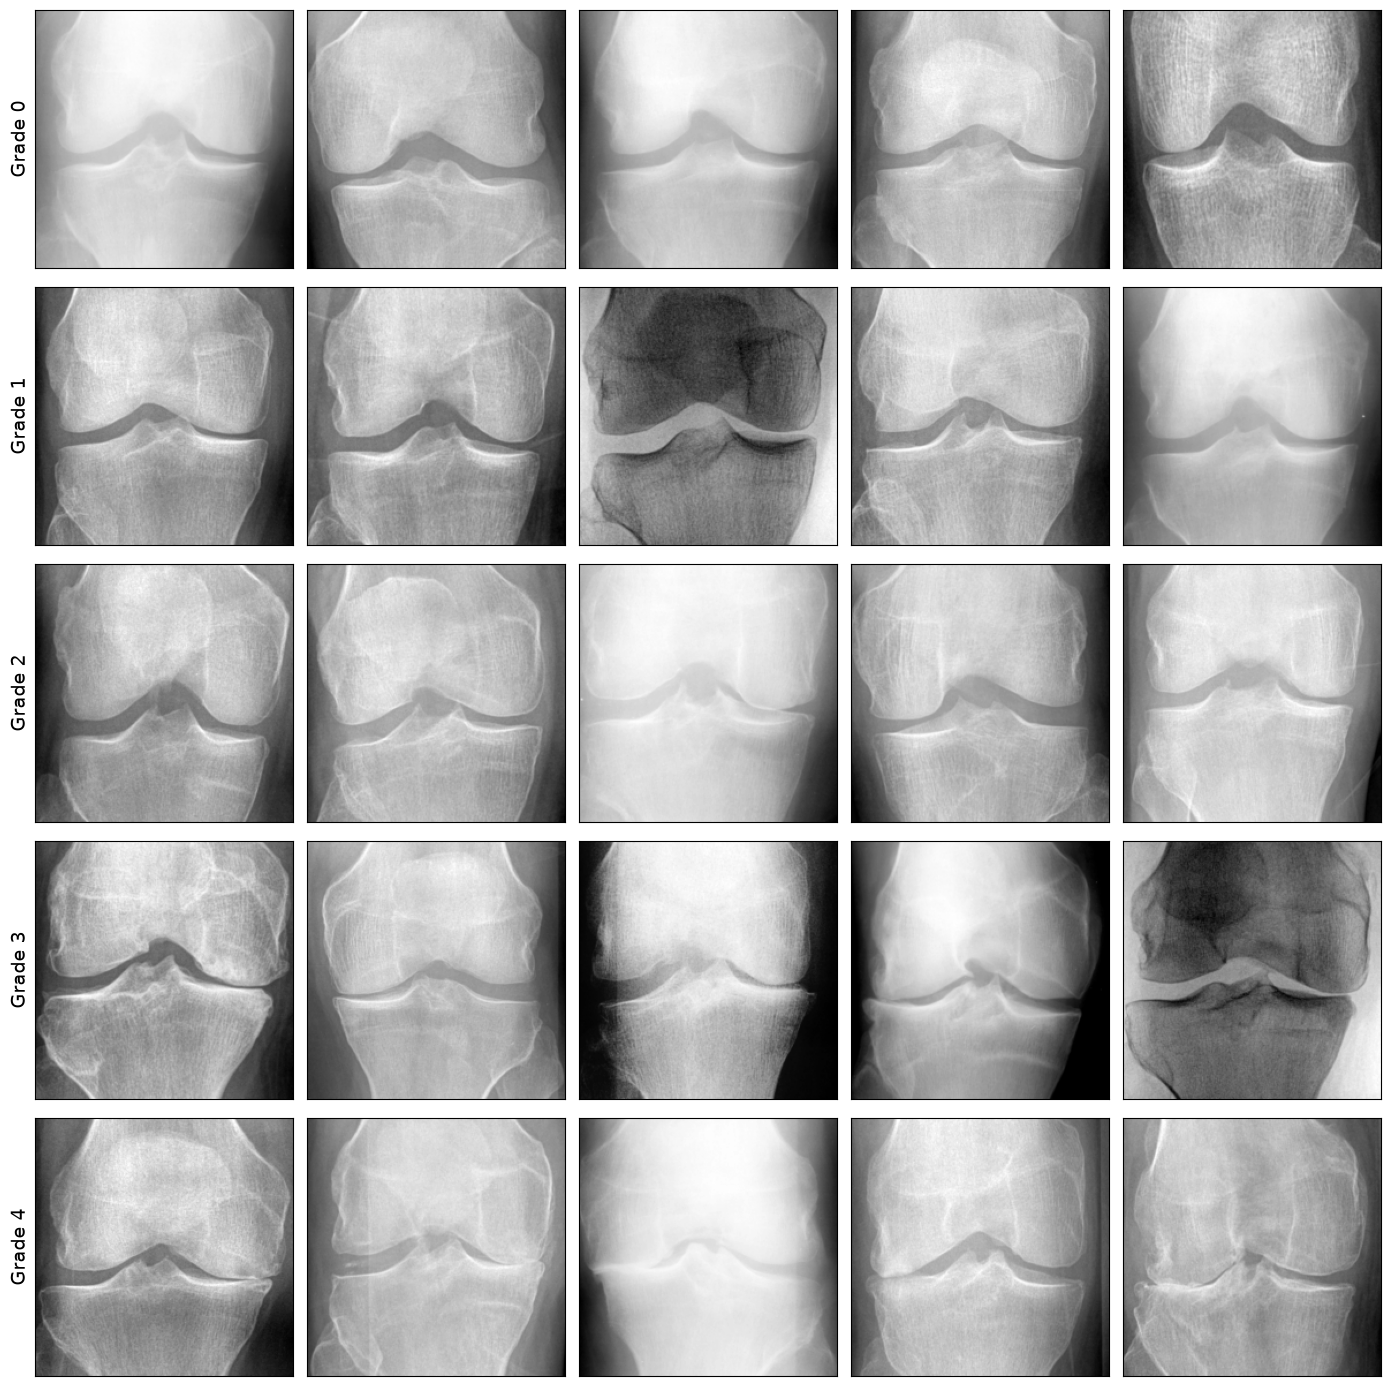

In [2]:
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
for g in GRADES:
    sample = df[(df.split == "train") & (df.grade == g)].path.sample(5, random_state=42)
    for j, p in enumerate(sample):
        img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
        ax = axes[g, j]
        ax.imshow(img, cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(f"Grade {g}", fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
props = []
for p in df.path:
    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    props.append({"shape": img.shape, "dtype": str(img.dtype), "ext": p.suffix.lower()})
pd.DataFrame(props).value_counts()

shape       dtype  ext 
(224, 224)  uint8  .png    8260
Name: count, dtype: int64

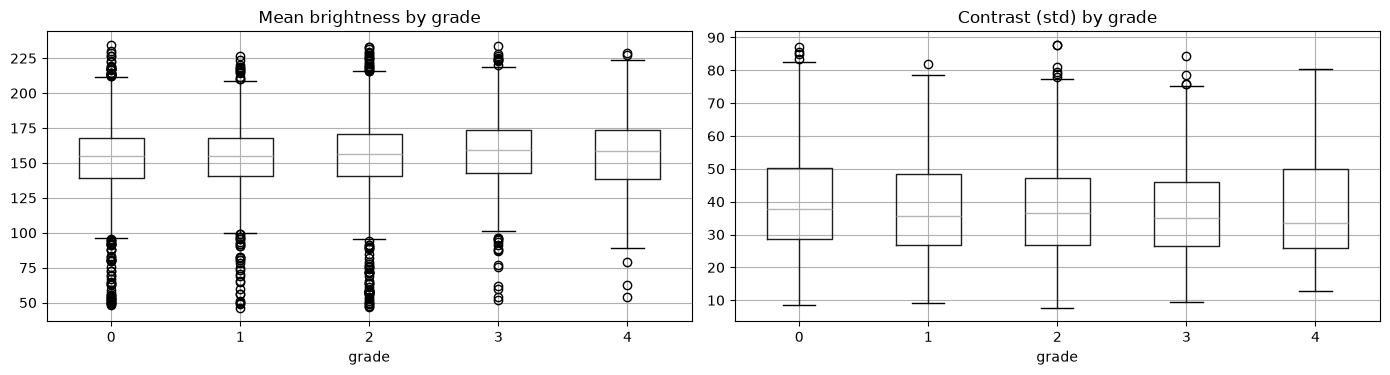

mean                                                    std        \
        count   mean   std   min    25%    50%    75%    max   count  mean   
grade                                                                        
0      3253.0  154.1  25.9  48.4  139.7  154.9  168.3  239.6  3253.0  39.8   
1      1495.0  153.4  26.6  45.9  140.5  154.6  168.1  226.9  1495.0  38.3   
2      2175.0  155.0  28.7  41.7  141.3  156.5  170.3  237.4  2175.0  37.6   
3      1086.0  158.5  28.1  49.7  142.4  159.0  174.0  236.9  1086.0  37.2   
4       251.0  160.0  30.6  54.3  145.3  160.6  177.2  229.0   251.0  37.5   

                                           
        std   min   25%   50%   75%   max  
grade                                      
0      14.6   8.5  28.4  37.3  49.7  87.2  
1      14.4   9.2  27.3  35.8  48.1  82.1  
2      14.1   7.5  26.4  36.0  47.1  87.8  
3      14.1   9.1  26.0  34.6  46.4  84.4  
4      14.7  12.8  25.4  34.1  48.7  80.4

In [4]:
stats = []
for p in df.path:
    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    stats.append({"mean": img.mean(), "std": img.std()})
df = pd.concat([df, pd.DataFrame(stats)], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df[df.split == "train"].boxplot(column="mean", by="grade", ax=axes[0])
df[df.split == "train"].boxplot(column="std", by="grade", ax=axes[1])
axes[0].set_title("Mean brightness by grade"); axes[1].set_title("Contrast (std) by grade")
plt.suptitle(""); plt.tight_layout(); plt.show()
df.groupby("grade")[["mean", "std"]].describe().round(1)

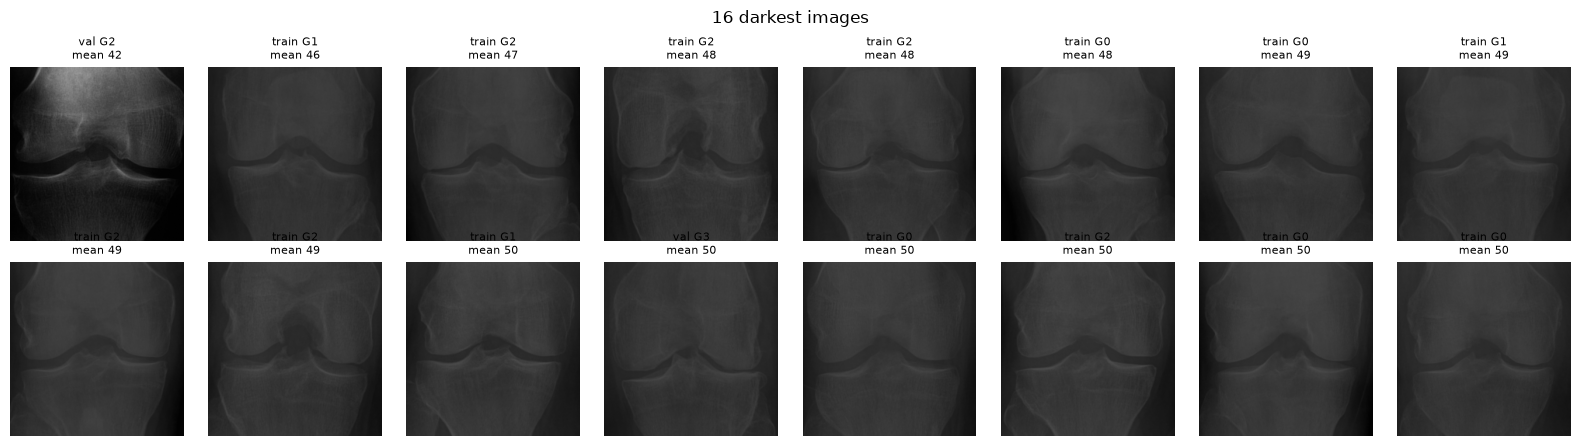

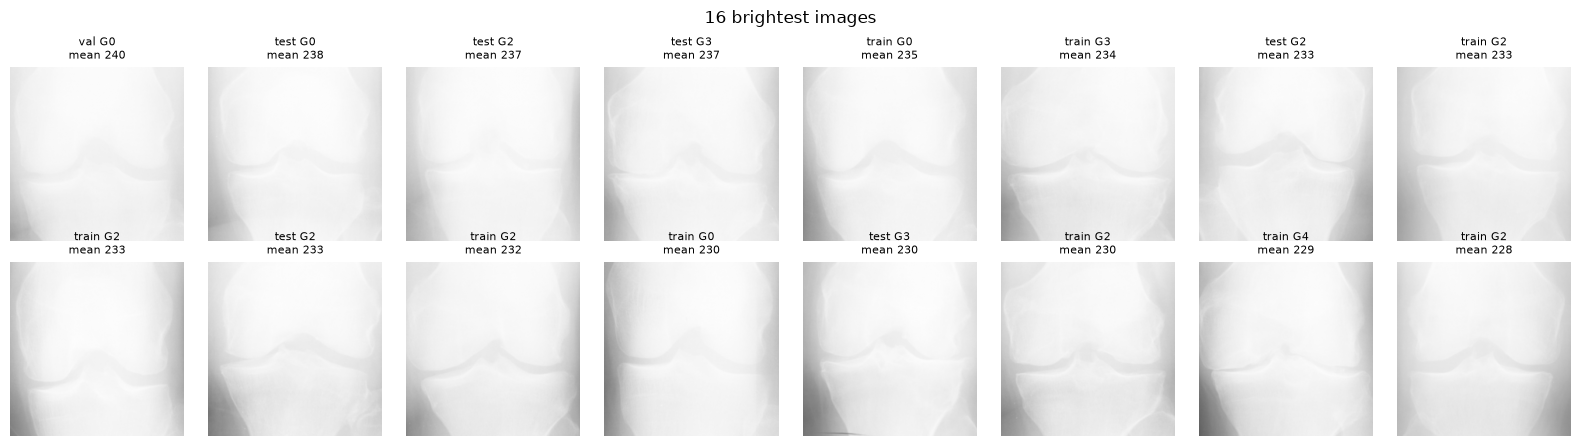

In [5]:
def show_grid(subset, title):
    fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
    for ax, (_, r) in zip(axes.flat, subset.iterrows()):
        ax.imshow(cv2.imread(str(r.path), cv2.IMREAD_UNCHANGED), cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{r.split} G{r.grade}\nmean {r['mean']:.0f}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_grid(df.nsmallest(16, "mean"), "16 darkest images")
show_grid(df.nlargest(16, "mean"), "16 brightest images")

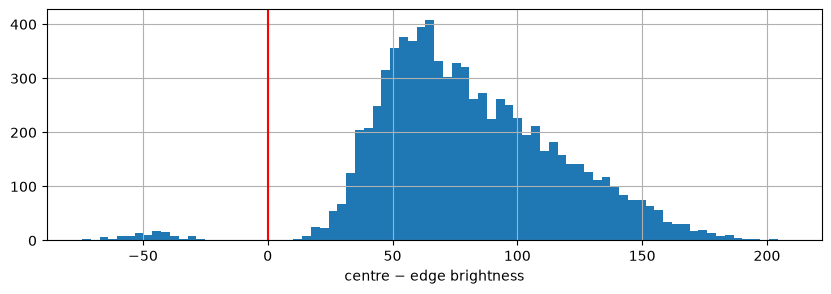

110 images with negative score


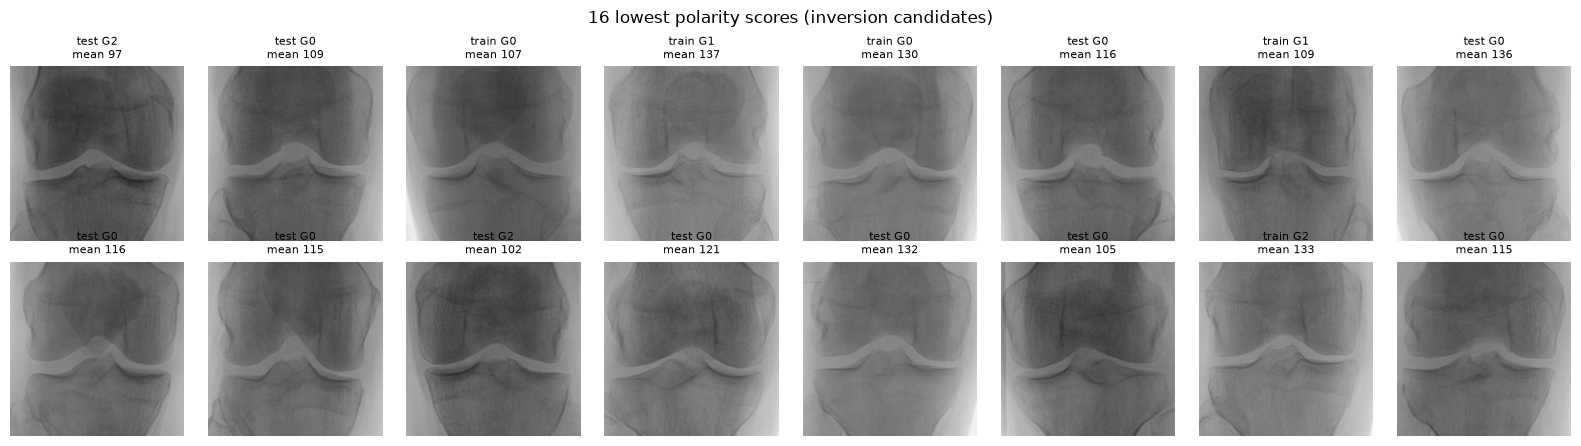

In [6]:
def polarity_score(img):
    center = img[40:184, 62:162].mean()
    border = np.concatenate([img[:, :20].ravel(), img[:, -20:].ravel()]).mean()
    return center - border

df["polarity"] = [polarity_score(cv2.imread(str(p), cv2.IMREAD_UNCHANGED)) for p in df.path]

df["polarity"].hist(bins=80, figsize=(10, 3))
plt.axvline(0, color="red"); plt.xlabel("centre − edge brightness"); plt.show()
print((df["polarity"] < 0).sum(), "images with negative score")
show_grid(df.nsmallest(16, "polarity"), "16 lowest polarity scores (inversion candidates)")

grade   0  1   2   3  4  All
split                       
test   17  0   6   3  0   26
train  28  8  23  10  1   70
val     3  0  10   1  0   14
All    48  8  39  14  1  110


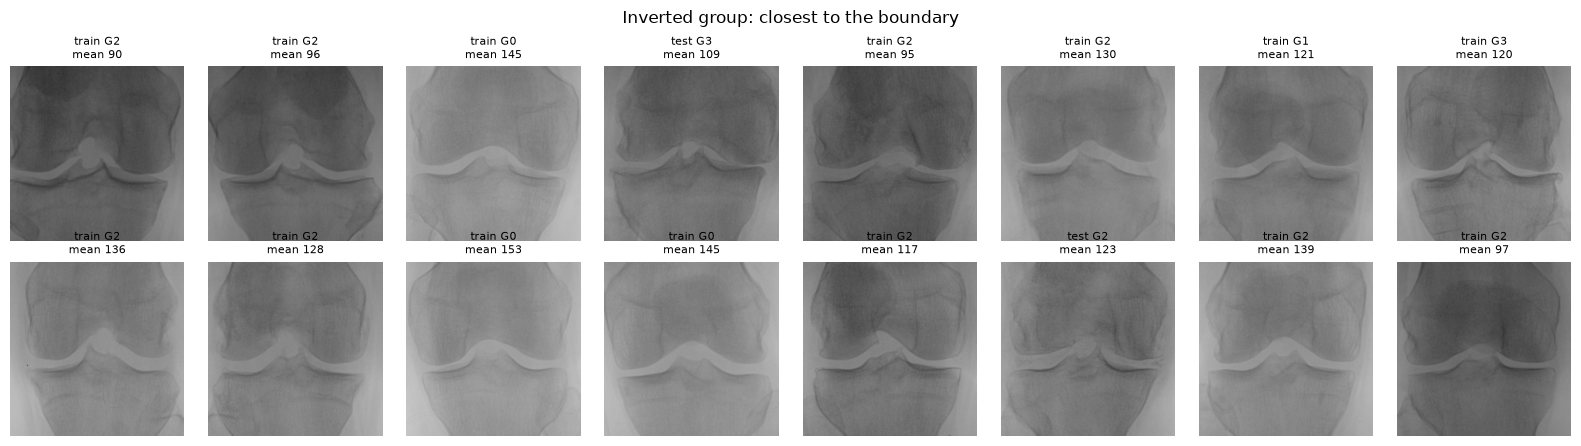

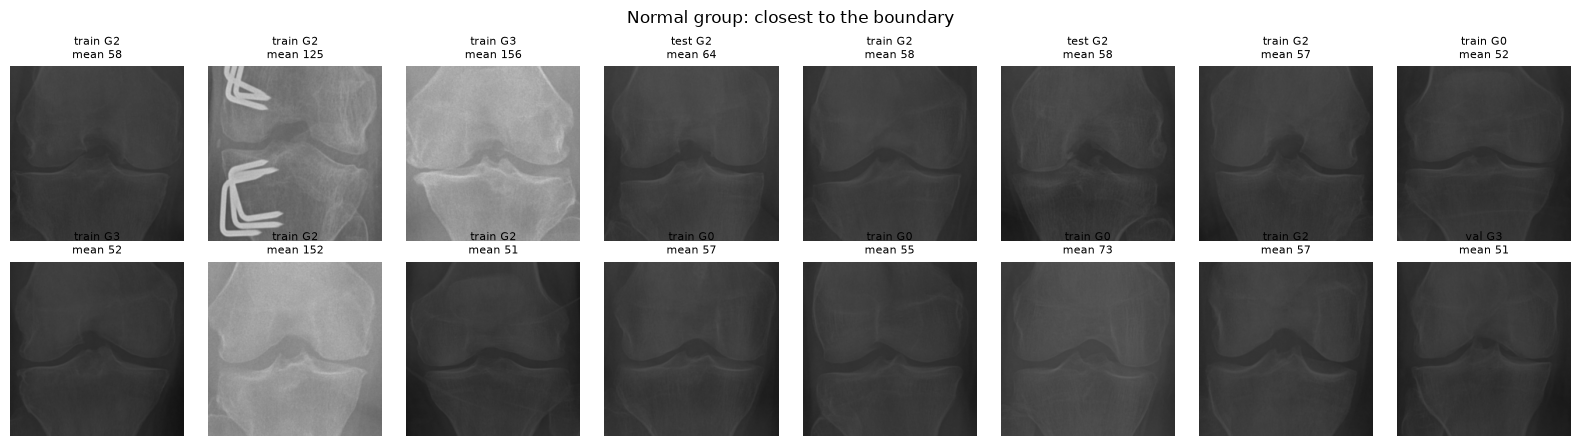

In [7]:
df["inverted"] = df["polarity"] < 0
print(pd.crosstab(df.split, df.grade, values=df.inverted.astype(int), aggfunc="sum", margins=True))

show_grid(df[df.inverted].nlargest(16, "polarity"), "Inverted group: closest to the boundary")
show_grid(df[~df.inverted].nsmallest(16, "polarity"), "Normal group: closest to the boundary")

In [9]:
from pathlib import Path
print(Path.cwd())

/home/afzal/projects/knee-oa-classification


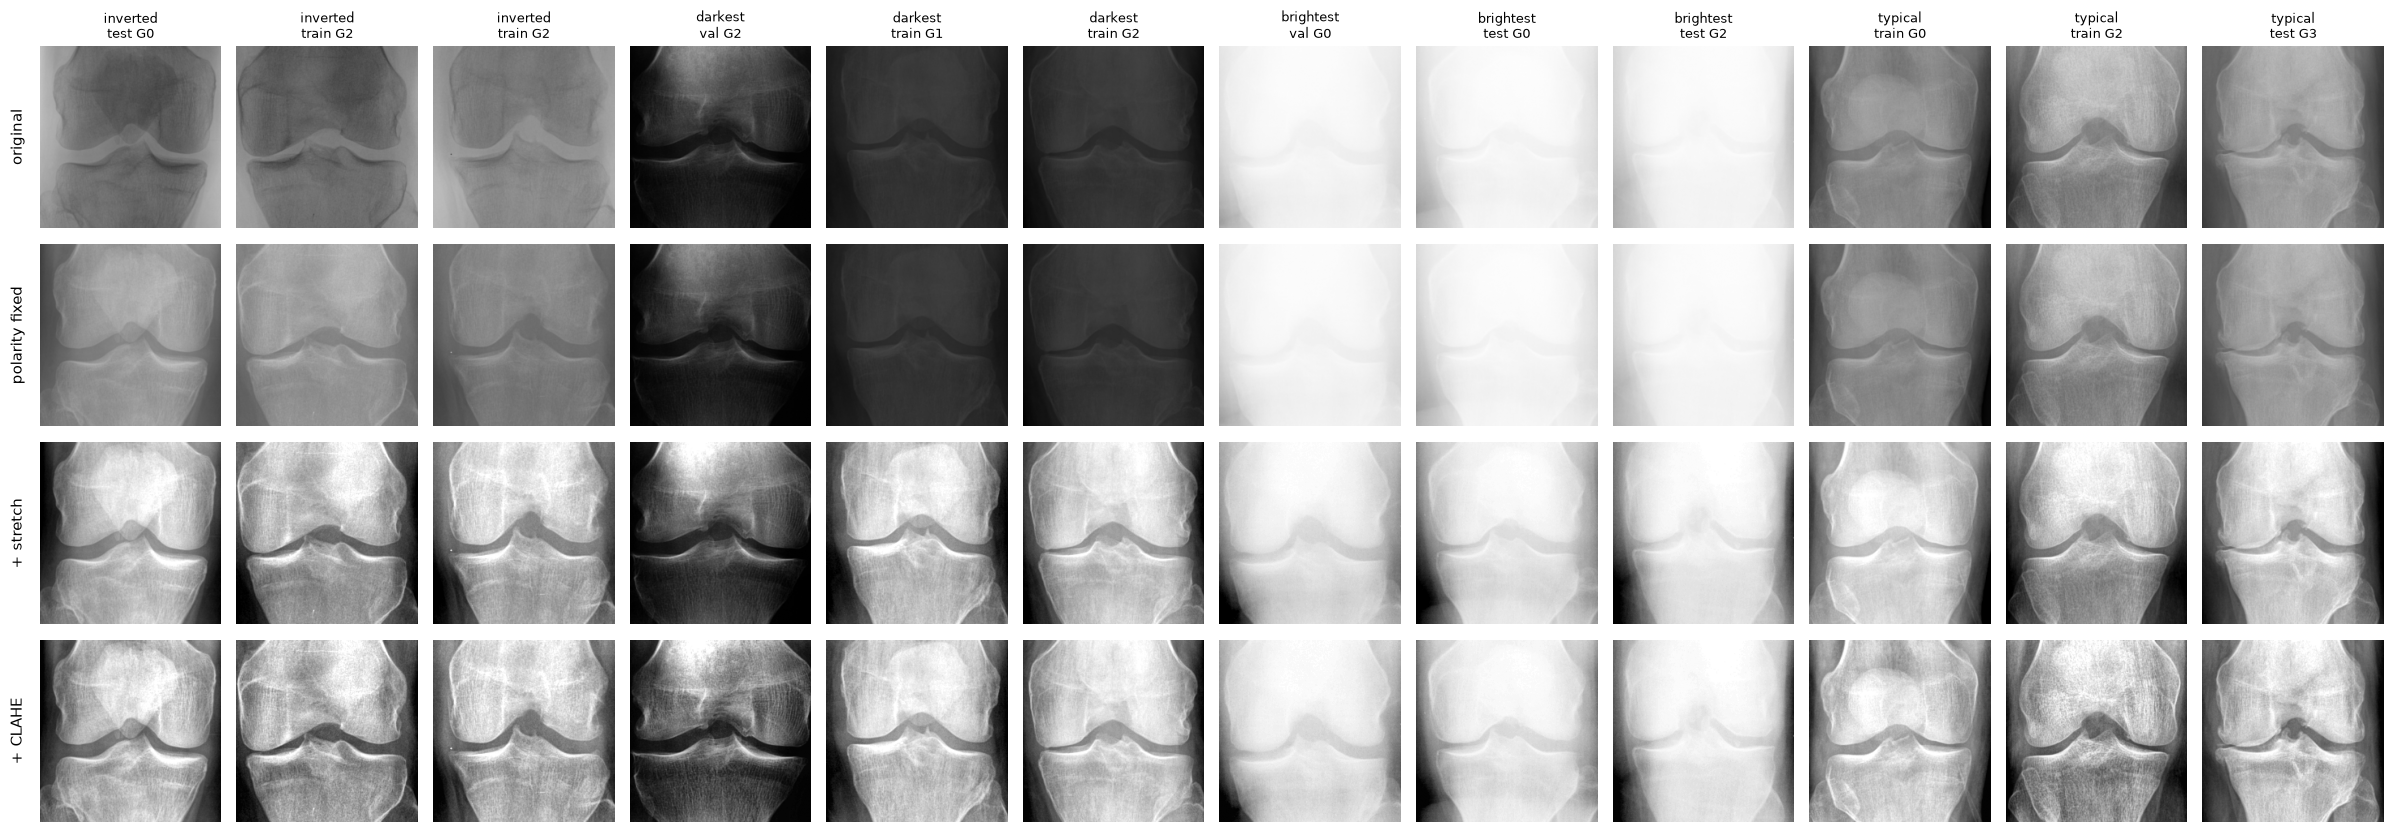

Saved to: /home/afzal/projects/knee-oa-classification/reports/preprocessing_comparison.png


In [10]:
from pathlib import Path

# --- Folder for saving figures (absolute path, works from anywhere) ---
PROJECT = Path.home() / "projects/knee-oa-classification"
REPORTS = PROJECT / "reports"
REPORTS.mkdir(exist_ok=True)

# --- Preprocessing steps ---
def fix_polarity(img):
    return 255 - img if polarity_score(img) < 0 else img

def stretch(img, lo=1, hi=99):
    p_lo, p_hi = np.percentile(img, (lo, hi))
    if p_hi <= p_lo:
        return img
    out = (img.astype(np.float32) - p_lo) * 255.0 / (p_hi - p_lo)
    return np.clip(out, 0, 255).astype(np.uint8)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def preprocess(img):
    return clahe.apply(stretch(fix_polarity(img)))

# --- Test images: 3 inverted, 3 darkest, 3 brightest, 3 typical ---
cases = pd.concat([
    df[df.inverted].sample(3, random_state=1).assign(group="inverted"),
    df.nsmallest(3, "mean").assign(group="darkest"),
    df.nlargest(3, "mean").assign(group="brightest"),
    df[~df.inverted].sample(3, random_state=1).assign(group="typical"),
])

# --- Before/after comparison: 4 rows x 12 images ---
fig, axes = plt.subplots(4, 12, figsize=(24, 8.5))
for j, (_, r) in enumerate(cases.iterrows()):
    raw = cv2.imread(str(r.path), cv2.IMREAD_UNCHANGED)
    fixed = fix_polarity(raw)
    stretched = stretch(fixed)
    for i, im in enumerate([raw, fixed, stretched, clahe.apply(stretched)]):
        axes[i, j].imshow(im, cmap="gray", vmin=0, vmax=255)
        axes[i, j].axis("off")
    axes[0, j].set_title(f"{r.group}\n{r.split} G{r.grade}", fontsize=9)
for i, label in enumerate(["original", "polarity fixed", "+ stretch", "+ CLAHE"]):
    axes[i, 0].text(-0.08, 0.5, label, rotation=90, transform=axes[i, 0].transAxes,
                    ha="right", va="center", fontsize=11)
plt.tight_layout()
plt.savefig(REPORTS / "preprocessing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to:", REPORTS / "preprocessing_comparison.png")

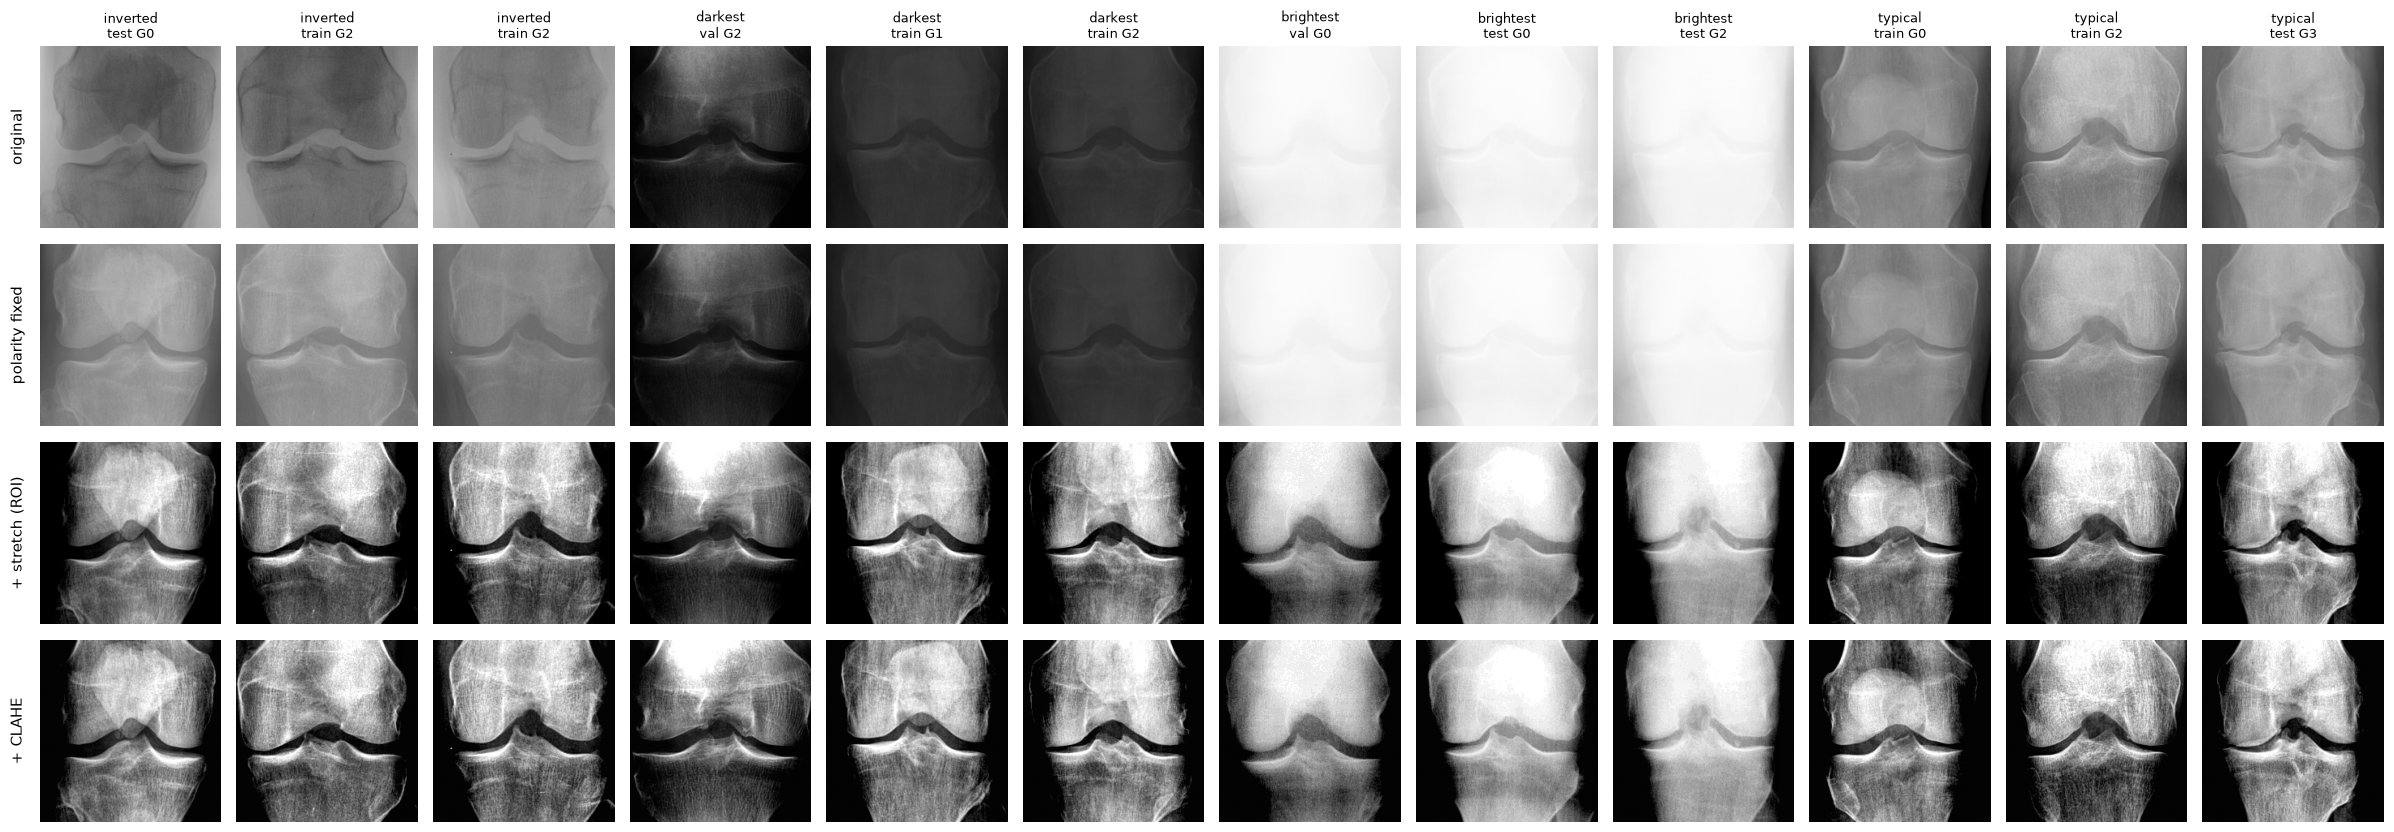

Saved to: /home/afzal/projects/knee-oa-classification/reports/preprocessing_comparison_v2.png


In [11]:
# --- Preprocessing steps ---
def fix_polarity(img):
    return 255 - img if polarity_score(img) < 0 else img

def stretch(img, lo=1, hi=99):
    roi = img[40:184, 40:184]                      # NEW: measure on the central joint region only
    p_lo, p_hi = np.percentile(roi, (lo, hi))
    if p_hi <= p_lo:
        return img
    out = (img.astype(np.float32) - p_lo) * 255.0 / (p_hi - p_lo)
    return np.clip(out, 0, 255).astype(np.uint8)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def preprocess(img):
    return clahe.apply(stretch(fix_polarity(img)))

# --- Before/after comparison: 4 rows x 12 images ---
fig, axes = plt.subplots(4, 12, figsize=(24, 8.5))
for j, (_, r) in enumerate(cases.iterrows()):
    raw = cv2.imread(str(r.path), cv2.IMREAD_UNCHANGED)
    fixed = fix_polarity(raw)
    stretched = stretch(fixed)
    for i, im in enumerate([raw, fixed, stretched, clahe.apply(stretched)]):
        axes[i, j].imshow(im, cmap="gray", vmin=0, vmax=255)
        axes[i, j].axis("off")
    axes[0, j].set_title(f"{r.group}\n{r.split} G{r.grade}", fontsize=9)
for i, label in enumerate(["original", "polarity fixed", "+ stretch (ROI)", "+ CLAHE"]):
    axes[i, 0].text(-0.08, 0.5, label, rotation=90, transform=axes[i, 0].transAxes,
                    ha="right", va="center", fontsize=11)
plt.tight_layout()
plt.savefig(REPORTS / "preprocessing_comparison_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to:", REPORTS / "preprocessing_comparison_v2.png")

In [12]:
%%writefile /home/afzal/projects/knee-oa-classification/src/preprocessing.py
"""Knee X-ray preprocessing: polarity fix -> ROI percentile stretch -> CLAHE."""
import cv2
import numpy as np

_CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def polarity_score(img):
    """Centre minus edge brightness. Negative means the image is inverted."""
    center = img[40:184, 62:162].mean()
    border = np.concatenate([img[:, :20].ravel(), img[:, -20:].ravel()]).mean()
    return center - border


def fix_polarity(img):
    return 255 - img if polarity_score(img) < 0 else img


def stretch(img, lo=1, hi=99):
    """Percentile contrast stretch, measured on the central joint region."""
    roi = img[40:184, 40:184]
    p_lo, p_hi = np.percentile(roi, (lo, hi))
    if p_hi <= p_lo:
        return img
    out = (img.astype(np.float32) - p_lo) * 255.0 / (p_hi - p_lo)
    return np.clip(out, 0, 255).astype(np.uint8)


def preprocess(img):
    return _CLAHE.apply(stretch(fix_polarity(img)))


def load_and_preprocess(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(path)
    return preprocess(img)

Writing /home/afzal/projects/knee-oa-classification/src/preprocessing.py


In [13]:
import sys, importlib
sys.path.insert(0, str(PROJECT / "src"))
import preprocessing as pp
importlib.reload(pp)

PROCESSED = PROJECT / "data/processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

for split in SPLITS:
    sub = df[df.split == split]
    X = np.stack([pp.load_and_preprocess(p) for p in sub.path])
    y = sub.grade.to_numpy(dtype=np.int64)
    np.savez(PROCESSED / f"{split}.npz", X=X, y=y)
    print(f"{split:5s}: X {X.shape} {X.dtype} | images per grade {np.bincount(y)}")

df.assign(path=df.path.astype(str)).to_csv(PROCESSED / "metadata.csv", index=False)
print("Saved to", PROCESSED)

train: X (5778, 224, 224) uint8 | images per grade [2286 1046 1516  757  173]
val  : X (826, 224, 224) uint8 | images per grade [328 153 212 106  27]
test : X (1656, 224, 224) uint8 | images per grade [639 296 447 223  51]
Saved to /home/afzal/projects/knee-oa-classification/data/processed


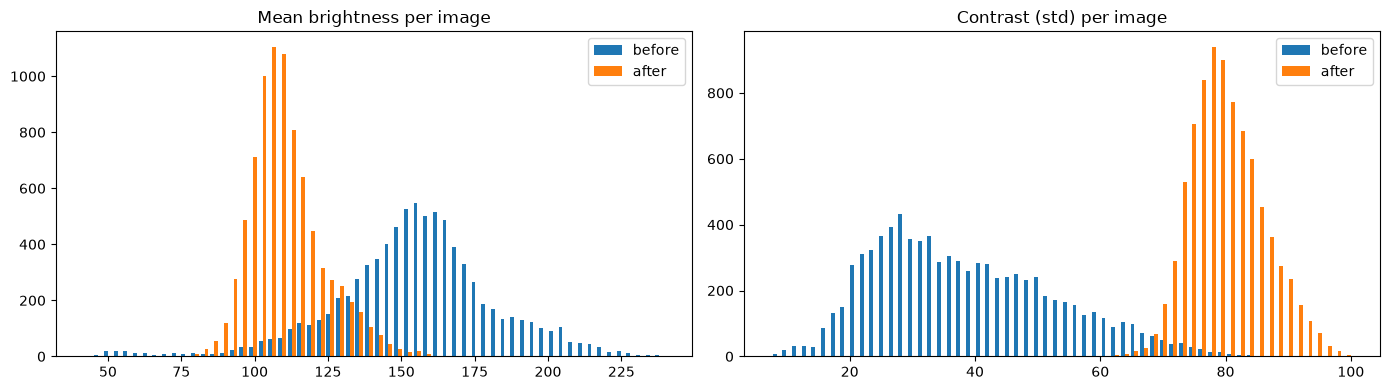

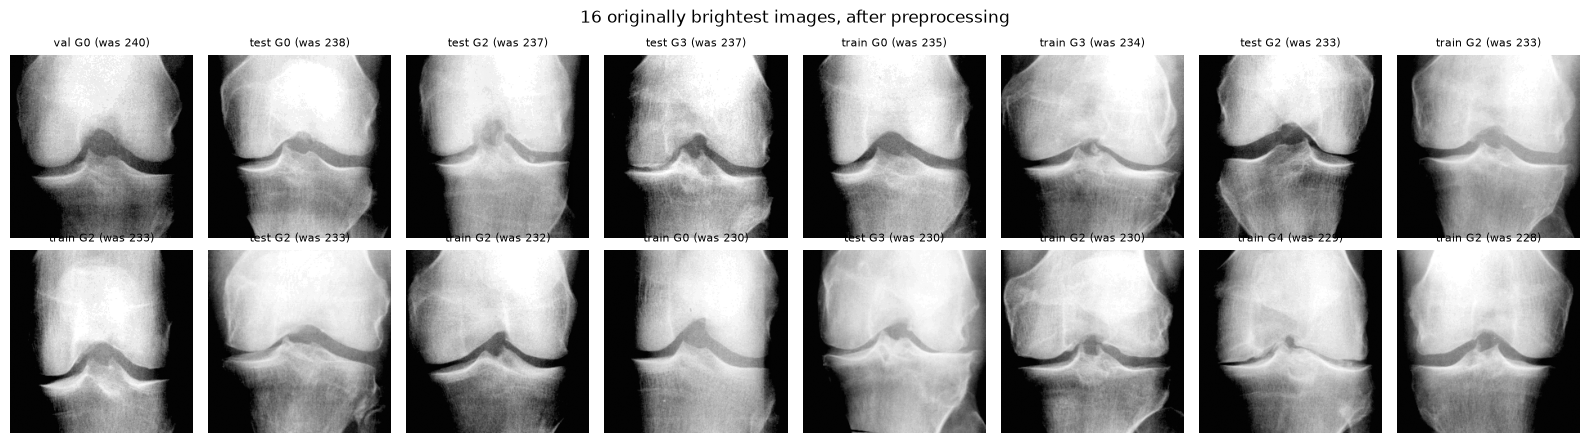

In [14]:
after = pd.concat([
    pd.DataFrame({"mean_after": (X := np.load(PROCESSED / f"{s}.npz")["X"]).mean(axis=(1, 2)),
                  "std_after": X.std(axis=(1, 2))})
    for s in SPLITS
], ignore_index=True)
df[["mean_after", "std_after"]] = after.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist([df["mean"], df["mean_after"]], bins=60, label=["before", "after"])
axes[0].set_title("Mean brightness per image"); axes[0].legend()
axes[1].hist([df["std"], df["std_after"]], bins=60, label=["before", "after"])
axes[1].set_title("Contrast (std) per image"); axes[1].legend()
plt.tight_layout(); plt.savefig(REPORTS / "intensity_before_after.png", dpi=150); plt.show()

bright = df.nlargest(16, "mean")
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, (_, r) in zip(axes.flat, bright.iterrows()):
    ax.imshow(pp.load_and_preprocess(r.path), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{r.split} G{r.grade} (was {r['mean']:.0f})", fontsize=8)
    ax.axis("off")
fig.suptitle("16 originally brightest images, after preprocessing")
plt.tight_layout(); plt.savefig(REPORTS / "brightest_after.png", dpi=150); plt.show()